In [5]:
import pandas as pd
import seaborn as sns
import numpy as nump
import sklearn.cluster as KMeans
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/Mall_Customers.csv')

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
display(df.describe())

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
print("Nilai Null Dataset: ")
df.isnull().sum()

Nilai Null Dataset: 


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [12]:
df.rename(columns={
    "Annual Income (k$)": 'Income',
    "Spending Score (1-100)": 'Spending'
}, inplace=True)

df.drop("CustomerID", axis=1, inplace=True)

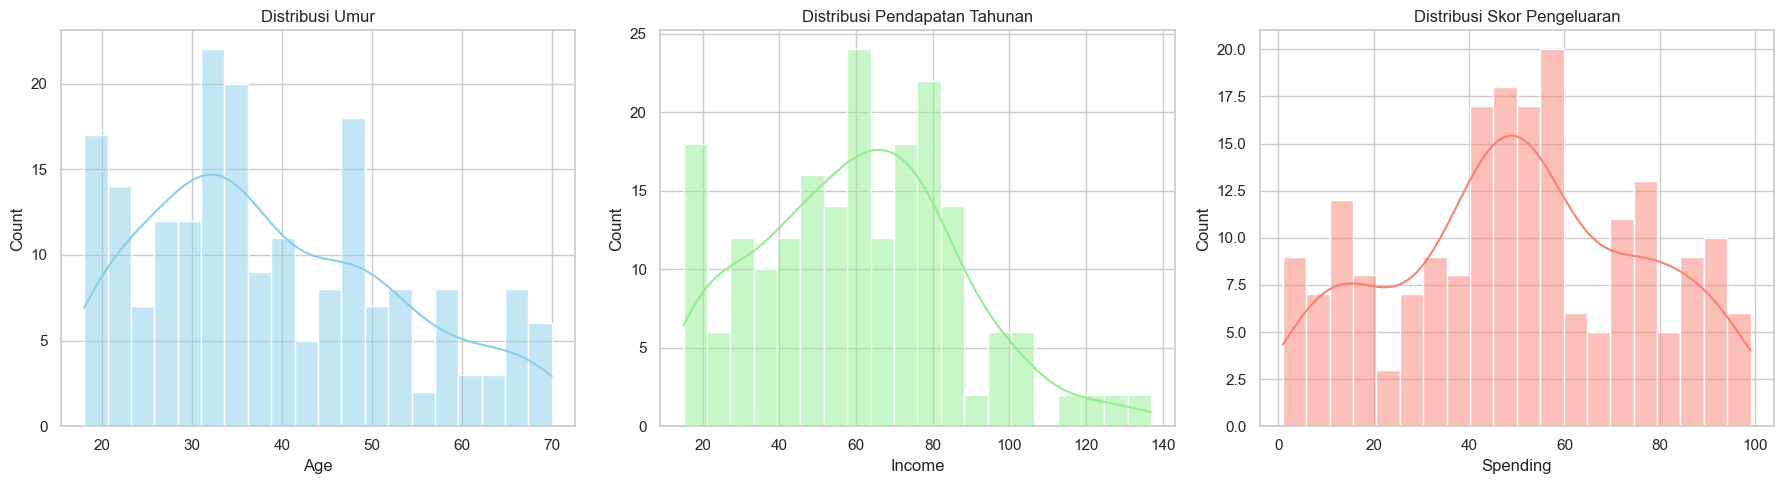

In [13]:
sns.set_theme(style="whitegrid")

# 2. Analisis Univariat (Distribusi masing-masing kolom)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Umur')

sns.histplot(df['Income'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribusi Pendapatan Tahunan')

sns.histplot(df['Spending'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribusi Skor Pengeluaran')

plt.tight_layout()
plt.show()

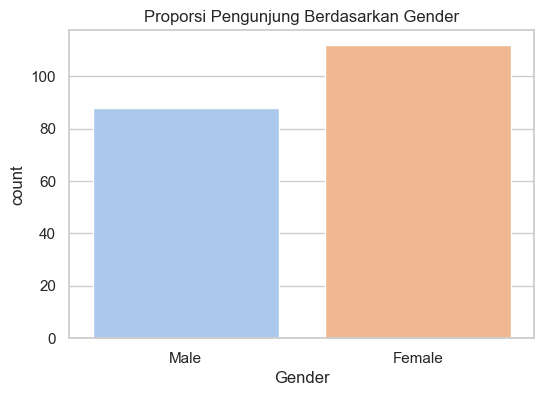

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Proporsi Pengunjung Berdasarkan Gender')
plt.show()

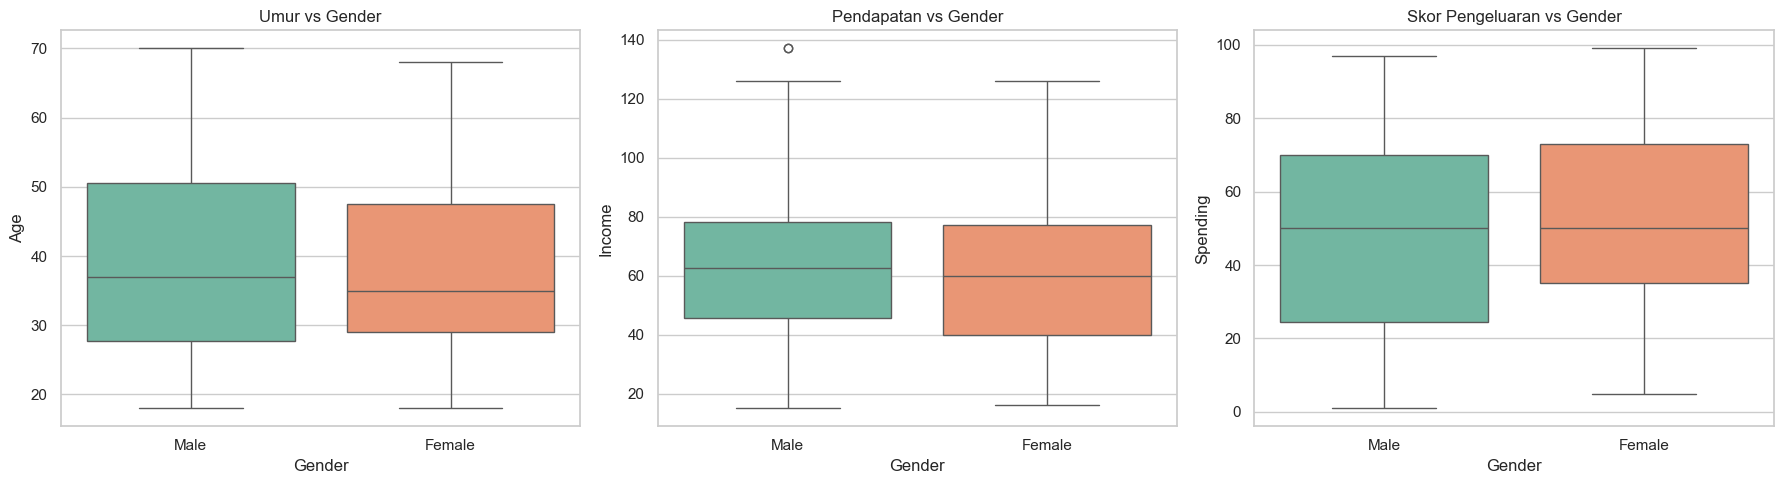

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Gender', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Umur vs Gender')

sns.boxplot(x='Gender', y='Income', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Pendapatan vs Gender')

sns.boxplot(x='Gender', y='Spending', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Skor Pengeluaran vs Gender')

plt.tight_layout()
plt.show()

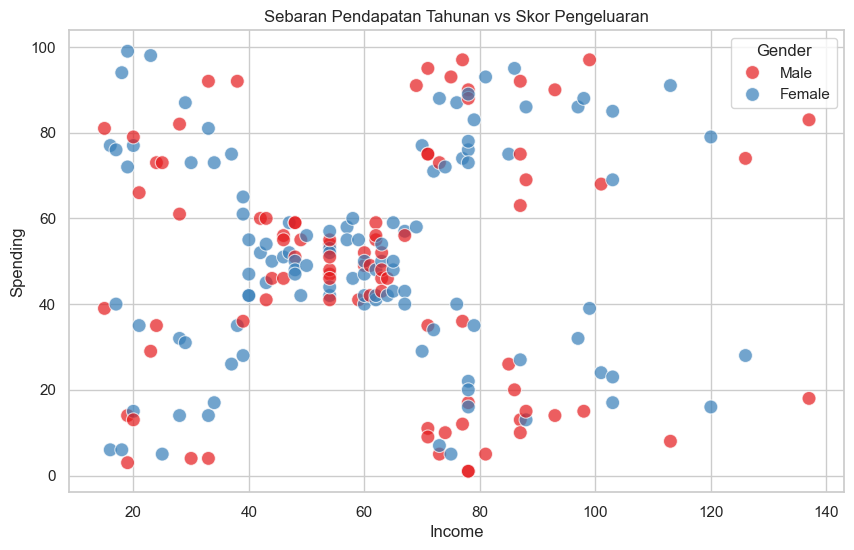

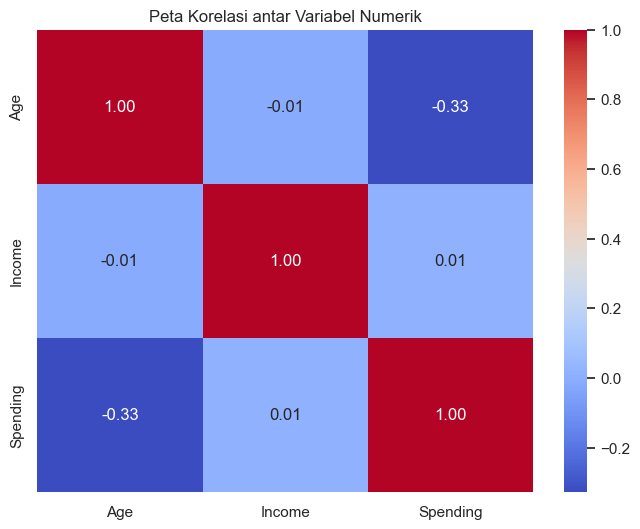

In [16]:
# 4. Analisis Korelasi (Mencari pola awal klastering)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending', hue='Gender', data=df, palette='Set1', s=100, alpha=0.7)
plt.title('Sebaran Pendapatan Tahunan vs Skor Pengeluaran')
plt.show()

# Heatmap Korelasi
plt.figure(figsize=(8, 6))
# Kita hanya mengambil kolom numerik untuk korelasi
numeric_cols = df[['Age', 'Income', 'Spending']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Peta Korelasi antar Variabel Numerik')
plt.show()

In [17]:
X = df[['Income', 'Spending']]

X.head()

,Income,Spending
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

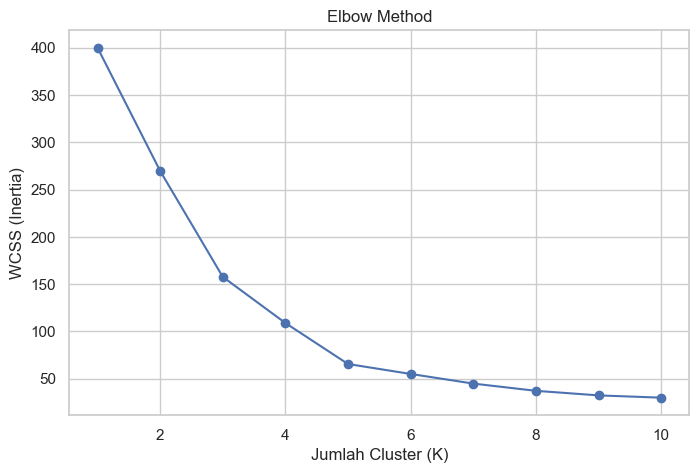

In [19]:
from sklearn.cluster import KMeans

wcss = []

for k in range (1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

K=2, Silhouette Score = 0.321
K=3, Silhouette Score = 0.467
K=4, Silhouette Score = 0.494
K=5, Silhouette Score = 0.555
K=6, Silhouette Score = 0.540
K=7, Silhouette Score = 0.528
K=8, Silhouette Score = 0.455
K=9, Silhouette Score = 0.457
K=10, Silhouette Score = 0.443


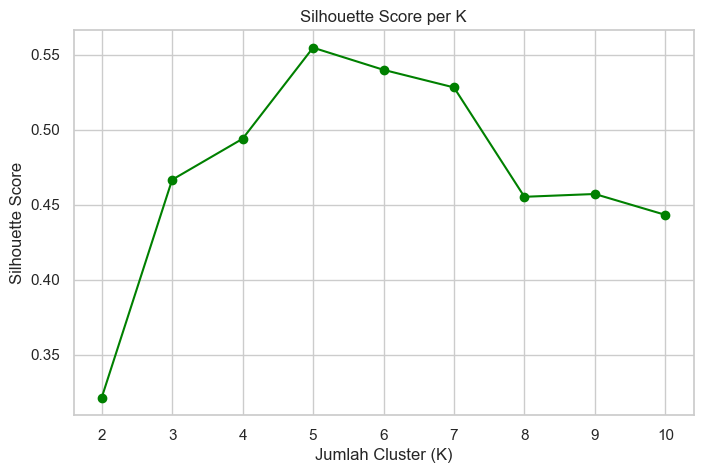

In [20]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score = {score:.3f}")

# Gambar grafik Silhouette
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker="o", color="green")
plt.title("Silhouette Score per K")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.show()

In [21]:
kmeans_final = KMeans(n_clusters=5, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

df.head()

,Gender,Age,Income,Spending,Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


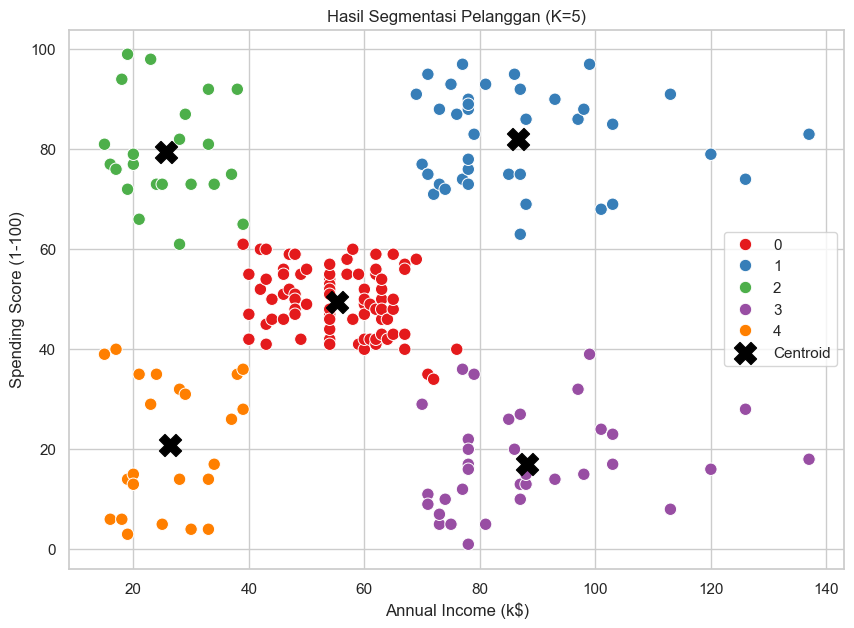

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Income", y="Spending", hue="Cluster",
                data=df, palette="Set1", s=80)

# Tampilkan titik pusat (centroid) tiap cluster
# Dikembalikan dulu ke skala asli dengan inverse_transform
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=250, c="black", marker="X", label="Centroid")

plt.title("Hasil Segmentasi Pelanggan (K=5)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [23]:
cluster_summary = df.groupby("Cluster")[["Age", "Income", "Spending"]].mean().round(1)
print(cluster_summary)

          Age  Income  Spending
Cluster                        
0        42.7    55.3      49.5
1        32.7    86.5      82.1
2        25.3    25.7      79.4
3        41.1    88.2      17.1
4        45.2    26.3      20.9


In [24]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [25]:
persona = {
    0: "Pelanggan Standar",      # income rendah, spending rendah
    1: "Target Utama (VIP)",   # income tinggi, spending rendah
    2: "Implusif",
    3: "Hemat/Konservatif",  # income tinggi, spending tinggi
    4: "Sensitif Harga"
}

df["Persona"] = df["Cluster"].map(persona)
df.head()

,Gender,Age,Income,Spending,Cluster,Persona
0,Male,19,15,39,4,Sensitif Harga
1,Male,21,15,81,2,Implusif
2,Female,20,16,6,4,Sensitif Harga
3,Female,23,16,77,2,Implusif
4,Female,31,17,40,4,Sensitif Harga


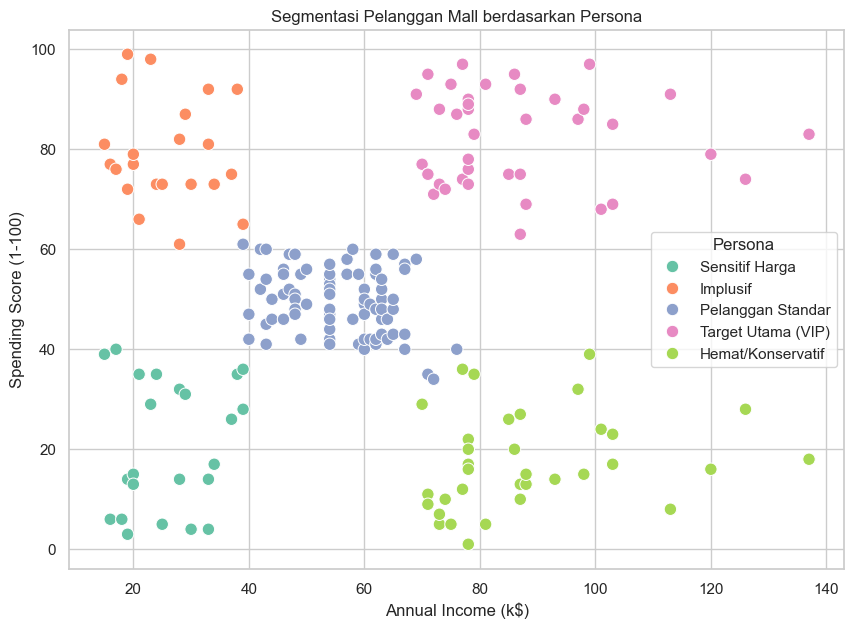

In [26]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Income", y="Spending", hue="Persona", data=df, palette="Set2", s=80)
plt.title("Segmentasi Pelanggan Mall berdasarkan Persona")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Persona")
plt.show()

In [27]:
import joblib

joblib.dump(kmeans_final, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

df.to_csv("customers_segmented.csv", index=False)

In [28]:
import json

info = {
    "centroids": kmeans_final.cluster_centers_.tolist(),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "persona": {
        "0": "Pelanggan Standar", "1": "Target Utama (VIP)",
        "2": "Implusif", "3": "Hemat/Konservatif", "4": "Sensitif Harga"
    }
}
with open("model_info.json", "w") as f:
    json.dump(info, f, indent=2)